In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from bgflow.utils import (assert_numpy, distance_vectors, distances_from_vectors, 
                          remove_mean, IndexBatchIterator, LossReporter, as_numpy, compute_distances
)
from bgflow import (GaussianMCMCSampler, DiffEqFlow, BoltzmannGenerator, Energy, Sampler, 
                    MultiDoubleWellPotential, MeanFreeNormalDistribution, 
                    KernelDynamics,BlackBoxDynamics, TimeIndependentDynamics, BruteForceEstimator, HutchinsonEstimator, DenseNet)

from bgflow.utils.autograd import brute_force_jacobian_trace

from tbg.gcl import E_GCL_vel, E_GCL, GCL
from tbg.models2 import EGNN


import time
import zuko

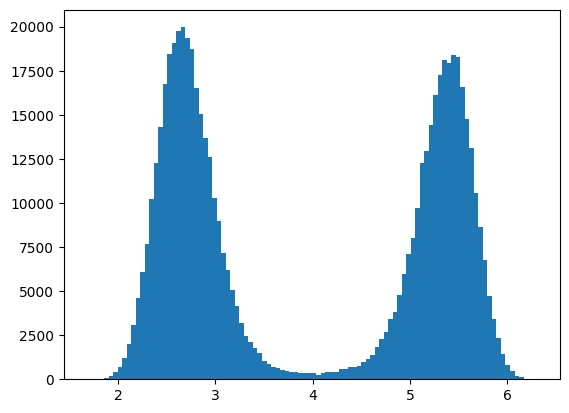

In [3]:
# first define system dimensionality and a target energy/distribution

dim = 8
n_particles = 4
n_dimensions = dim // n_particles

# DW parameters
a=0.9
b=-4
c=0
offset=4

target = MultiDoubleWellPotential(dim, n_particles, a, b, c, offset, two_event_dims=False)

# define a MCMC sampler to sample from the target energy

dw4_data = np.load("../data/dw4-dataidx.npy", allow_pickle=True)
all_data = remove_mean(dw4_data[0], n_particles, n_dimensions)
idx = dw4_data[1]
data = all_data[idx[:100000]]
val_data = all_data[idx[100000:500000]]
data_holdout = all_data[idx[-500000:]]
data_holdout.shape

dists_data = as_numpy(compute_distances(data, n_particles, n_dimensions))

plt.hist(dists_data.reshape(-1), bins=100);

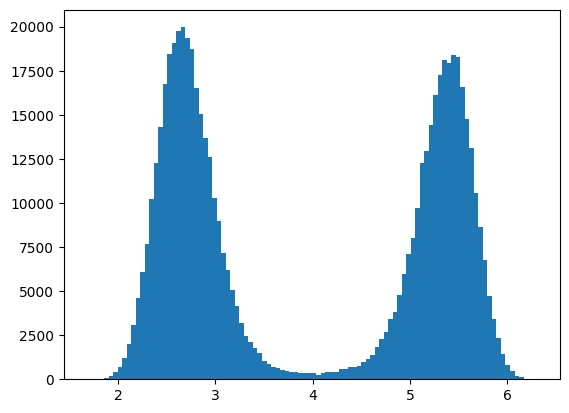

In [4]:
n_data = 100000
data_smaller = data[:n_data].clone()
data_smaller = data_smaller
data_smaller.shape

PATH = "models/DW4_equivariant_nODE-egnn-100000"


dists_data = as_numpy(compute_distances(data_smaller, n_particles, n_dimensions))

plt.hist(dists_data.reshape(-1), bins=100);

In [5]:
# # now set up a prior
# prior =  MeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()

# now set up a prior
class MyMeanFreeNormalDistribution(Energy, Sampler):
    """ Mean-free normal distribution. """

    def __init__(self, dim, n_particles, std=1., two_event_dims=True):
        if two_event_dims:
            super().__init__([n_particles, dim // n_particles])
        else:
            super().__init__(dim)
        self._two_event_dims = two_event_dims
        self._dim = dim
        self._n_particles = n_particles
        self._spacial_dims = dim // n_particles
        self.register_buffer("_std", torch.as_tensor(std))

    def forward(self, n_samples, temperature=1.):
        samples = self.sample(n_samples, temperature)
        energy = 0.5 * samples.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2
        return samples, energy.squeeze()
        
    def _energy(self, x):
        x = self._remove_mean(x).view(-1, self._dim)
        # TODO: make consistent
        return 0.5 * x.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2

    def sample(self, n_samples, temperature=1.):
        x = torch.ones((n_samples, self._n_particles, self._spacial_dims), dtype=self._std.dtype,
                         device=self._std.device).normal_(mean=0, std=self._std)
        x = self._remove_mean(x)
        if not self._two_event_dims:
            x = x.view(-1, self._dim)
        return x

    def _remove_mean(self, x):
        x = x.view(-1, self._n_particles, self._spacial_dims)
        x = x - torch.mean(x, dim=1, keepdim=True)
        return x

prior =  MyMeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()

In [6]:
from tbg.utils import remove_mean as tbg_remove_mean

class EGNN_dynamics_consistency(nn.Module):
    def __init__(
        self,
        n_particles,
        n_dimension,
        hidden_nf=64,
        device="cpu",
        act_fn=torch.nn.SiLU(),
        n_layers=4,
        recurrent=True,
        attention=False,
        condition_time=True,
        tanh=False,
        mode="egnn_dynamics",
        agg="sum",
    ):
        super().__init__()
        self.mode = mode
        if mode == "egnn_dynamics":
            self.egnn = EGNN(
                in_node_nf=2,
                in_edge_nf=1,
                hidden_nf=hidden_nf,
                device=device,
                act_fn=act_fn,
                n_layers=n_layers,
                recurrent=recurrent,
                attention=attention,
                tanh=tanh,
                agg=agg,
            )

        self.device = device
        self._n_particles = n_particles
        self._n_dimension = n_dimension
        self.edges = self._create_edges()
        self._edges_dict = {}
        self.condition_time = condition_time
        # Count function calls
        self.counter = 0

    def forward(self, t, xs, d=None):

        n_batch = xs.shape[0]
        edges = self._cast_edges2batch(self.edges, n_batch, self._n_particles)
        edges = [edges[0], edges[1]]
        x = xs.reshape(n_batch * self._n_particles, self._n_dimension).clone()
        h = torch.ones(n_batch, self._n_particles, 2).to(self.device)
        t = torch.tensor(t).to(xs)
        if t.shape != (n_batch, 1):
            t = t.repeat(n_batch)
        t = t.reshape(n_batch, 1)
        if d is None:
            d = torch.zeros_like(t)

        td = torch.cat([t, d], dim=-1)
        if self.condition_time:
            h = h * td.unsqueeze(1)
        h = h.reshape(n_batch * self._n_particles, 2)
        if self.mode == "egnn_dynamics":
            edge_attr = torch.sum((x[edges[0]] - x[edges[1]]) ** 2, dim=1, keepdim=True)
            _, x_final = self.egnn(h, x, edges, edge_attr=edge_attr)
            vel = x_final - x

        elif self.mode == "gnn_dynamics":
            h = torch.cat([h, x], dim=1)
            vel = self.gnn(h, edges)

        vel = vel.view(n_batch, self._n_particles, self._n_dimension)
        vel = tbg_remove_mean(vel)
        self.counter += 1
        return vel.view(n_batch, self._n_particles * self._n_dimension)

    def _create_edges(self):
        rows, cols = [], []
        for i in range(self._n_particles):
            for j in range(i + 1, self._n_particles):
                rows.append(i)
                cols.append(j)
                rows.append(j)
                cols.append(i)
        return [torch.LongTensor(rows), torch.LongTensor(cols)]

    def _cast_edges2batch(self, edges, n_batch, n_nodes):
        if n_batch not in self._edges_dict:
            self._edges_dict = {}
            rows, cols = edges
            rows_total, cols_total = [], []
            for i in range(n_batch):
                rows_total.append(rows + i * n_nodes)
                cols_total.append(cols + i * n_nodes)
            rows_total = torch.cat(rows_total).to(self.device)
            cols_total = torch.cat(cols_total).to(self.device)

            self._edges_dict[n_batch] = [rows_total, cols_total]
        return self._edges_dict[n_batch]    

In [7]:
from tarflow import Model
from ema_pytorch import EMA
import math

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

img_size = 8
channel_size = 1

# we use a small model for fast demonstration, increase the model size for better results
patch_size = 1
channels = 128
blocks = 8
layers_per_block = 4
# try different noise levels to see its effect
noise_std = 0.1
n_epochs=100
dim = 8

tarflow = Model(in_channels=channel_size, img_size=img_size, patch_size=patch_size, 
              channels=channels, num_blocks=blocks, layers_per_block=layers_per_block).to(device)
ema_tarflow = Model(in_channels=channel_size, img_size=img_size, patch_size=patch_size, 
              channels=channels, num_blocks=blocks, layers_per_block=layers_per_block).to(device)

ema = EMA(
    tarflow,
    beta = 0.999,              # exponential moving average factor
    update_after_step = 5_000,    # only after this number of .update() calls will it start updating
    update_every = 1,          # how often to actually update, to save on compute (updates every 10th .update() call)
)


class CosineLRSchedule(torch.nn.Module):
    counter: torch.Tensor

    def __init__(self, optimizer, warmup_steps: int, total_steps: int, min_lr: float, max_lr: float):
        super().__init__()
        self.register_buffer('counter', torch.zeros(()))
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.optimizer = optimizer
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.set_lr(min_lr)

    def set_lr(self, lr: float) -> float:
        if self.min_lr <= lr <= self.max_lr:
            for pg in self.optimizer.param_groups:
                pg['lr'] = lr
        return max(self.min_lr, min(self.max_lr, lr))

    def step(self) -> float:
        with torch.no_grad():
            counter = self.counter.add_(1).item()
        if self.counter <= self.warmup_steps:
            new_lr = self.min_lr + counter / self.warmup_steps * (self.max_lr - self.min_lr)
            return self.set_lr(new_lr)

        t = (counter - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        new_lr = self.min_lr + 0.5 * (1 + math.cos(math.pi * t)) * (self.max_lr - self.min_lr)
        return self.set_lr(new_lr)


net_dynamics = EGNN_dynamics_consistency(n_particles=n_particles, device='cuda',  n_dimension=dim // n_particles, hidden_nf=256,
    act_fn=torch.nn.SiLU(), n_layers=5, recurrent=True, tanh=True, attention=True, condition_time=True, mode='egnn_dynamics', agg='sum')


8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8


In [8]:
# Initialize divergence estimators
brute_force_estimator = BruteForceEstimator()

bb_dynamics = BlackBoxDynamics(
    dynamics_function=net_dynamics,
    divergence_estimator=brute_force_estimator
)

flow = DiffEqFlow(
    dynamics=bb_dynamics
)

# having a flow and a prior, we can now define a Boltzmann Generator

bg = BoltzmannGenerator(prior, flow, target).cuda()

# use DTO in the training process
flow._use_checkpoints = True

# Anode options
options={
    "Nt": 20,
    "method": "RK4"
}
flow._kwargs = options

# train with convex mixture of NLL and KL loss

n_kl_samples = 512
n_batch = 512
batch_iter = IndexBatchIterator(len(data_smaller), n_batch)

optim = torch.optim.Adam(net_dynamics.parameters())
tarflow_optimizer = torch.optim.AdamW(tarflow.parameters(), 5e-4, weight_decay=1e-3)


n_epochs = 80
# lr_schedule_flow = CosineLRSchedule(optim, len(batch_iter), n_epochs * len(batch_iter), 1e-6, 5e-4)
lr_schedule_tarflow = CosineLRSchedule(tarflow_optimizer, len(batch_iter), n_epochs * len(batch_iter), 1e-6, 5e-4)

n_report_steps = 5

# mixing parameter

reporter = LossReporter("NLL", "Consistency")
val_losses = []

In [9]:
# start with 5e-4

for g in optim.param_groups:
     g['lr'] = 5e-4

d_values = torch.tensor([1/128, 1/64, 1/32, 1/16,1/8,1/4, 1/2])

In [10]:
# import pdb 

# sigma = 0.00
# losses = []
# tarflow_training = 'MLE'
# n_epochs = 20
# print(n_epochs)
# for epoch in range(n_epochs):
#     if epoch ==200:
#         for g in optim.param_groups:
#              g['lr'] = 5e-5
#     for it, idxs in enumerate(batch_iter):
    
#         optim.zero_grad()
#         # tarflow_optimizer.zero_grad()
        
#         x1 = data_smaller[idxs].cuda()
#         batchsize = x1.shape[0]
#         t = torch.rand(batchsize, 1).cuda()
#         indices = torch.randint(0, len(d_values), (batchsize,))
#         d = d_values[indices].unsqueeze(-1).cuda()
#         d_input = d.clone()
#         d_input[d_input<1/100] = 0
        
#         x0 = prior.sample(batchsize)

#         mu_t = x0 * (1 - t) + x1 * t
#         sigma_t = sigma
#         noise = prior.sample(batchsize)
#         x = mu_t + sigma_t * noise
#         ut = x1 - x0
#         vt = bg.flow._dynamics._dynamics._dynamics_function(t, x)
#         loss = torch.mean((vt - ut) ** 2)
#         s_t = bg.flow._dynamics._dynamics._dynamics_function(t, x, d_input)
        
#         # use mu_t here directly?
#         x_td = x + s_t * d
#         s_td = bg.flow._dynamics._dynamics._dynamics_function(t+d, x_td, d_input)
#         s_target = (s_t + s_td).detach() / 2
#         v_td = bg.flow._dynamics._dynamics._dynamics_function(t, x, 2*d)
#         consistency_loss = torch.mean((v_td - s_target) ** 2)
#         total_loss = loss + consistency_loss
#         if not torch.isnan(total_loss) and not torch.isinf(total_loss):
#             total_loss.backward()
#             torch.nn.utils.clip_grad_norm_(net_dynamics.parameters(), 1.0)
#             torch.nn.utils.clip_grad_value_(net_dynamics.parameters(), 1.0)
#             optim.step()


#         # use_coupling_flow = torch.abs(2*d - 1) < 1e-4
#         # coupling_target = v_td[use_coupling_flow.squeeze()].detach() + x0[use_coupling_flow.squeeze()]
        
#         # x1_hat, v_coupling_flow, logdets = tarflow(x0[use_coupling_flow.squeeze()])

#         # ### Regression or MLE

#         # if tarflow_training == 'regression':
#         #     tarflow_loss = torch.mean((x1_hat - coupling_target) ** 2)
#         # else:
#         #     tarflow_loss = tarflow.get_loss_mean_free(prior, x1_hat, logdets)
        
#         # losses.append(tarflow_loss)

#         # if not torch.isnan(tarflow_loss):
#         #     tarflow_loss.backward()
#         #     torch.nn.utils.clip_grad_norm_(tarflow.parameters(), 1.0)
#         #     torch.nn.utils.clip_grad_value_(tarflow.parameters(), 1.0)
#         #     tarflow_optimizer.step()
#         #     lr_schedule_tarflow.step()
#         #     ema.update()
        
#         #break
#         reporter.report(loss, consistency_loss)
#         if it % n_report_steps == 0:
#             print("\repoch: {0}, iter: {1}/{2}, loss: {3:.4}, consistency_loss: {4:.4}".format(
#                     epoch,
#                     it,
#                     len(batch_iter),
#                     *reporter.recent(1).ravel()
#                 ), end="")
#         # if it % n_report_steps == 0:
#         #     print("\repoch: {0}, iter: {1}/{2}, loss: {3:.4}, consistency_loss: {4:.4}, tarflow_loss: {5:.4}".format(
#         #             epoch,
#         #             it,
#         #             len(batch_iter),
#         #             *reporter.recent(1).ravel(),
#         #             tarflow_loss.item()
#         #         ), end="")

In [11]:
PATH = "models/DW4_shortcut_non_invertible_one_tarflow"
PATH_SHORTCUT = "models/DW4_shortcut_shortcut"
#torch.save(tarflow.state_dict(), PATH)
#tarflow.load_state_dict(torch.load(PATH))
#torch.save(net_dynamics.state_dict(), PATH_SHORTCUT)
net_dynamics.load_state_dict(torch.load(PATH_SHORTCUT))

/tmp/ipykernel_4151471/2069789748.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_dynamics.load_state_dict(torch.load(PATH_SHORTCUT))


<All keys matched successfully>

In [12]:
class BruteForceEstimatorFast(torch.nn.Module):
    """
    Exact bruteforce estimation of the divergence of a dynamics function.
    """

    def __init__(self):
        super().__init__()

    def forward(self, dynamics, t, xs):
        """
        Computes the change of the system `dxs` due to a time independent dynamics function.
        Furthermore, also computes the exact change of log density
        which is equal to the divergence of the change `dxs`.

        Parameters
        ----------
        dynamics : torch.nn.Module
            A dynamics function that computes the change of the system and its density.
        t : PyTorch tensor
            The current time
        xs : PyTorch tensor
            The current configuration of the system

        Returns
        -------
        dxs, -divergence: PyTorch tensors
            The combined state update of shape `[n_batch, n_dimensions]`
            containing the state update of the system state `dx/dt`
            (`dxs`) and the negative update of the log density (`-divergence`)
        """

        with torch.set_grad_enabled(True):
            xs.requires_grad_(True)
            x = [xs[:, [i]] for i in range(xs.size(1))]

            dxs = dynamics(t, torch.cat(x, dim=1))

            assert len(dxs.shape) == 2, "`dxs` must have shape [n_btach, system_dim]"
            divergence = 0
            for i in range(xs.size(1)):
                divergence += torch.autograd.grad(dxs[:, [i]], x[i], torch.ones_like(dxs[:, [i]]), retain_graph=True)[0]

        return dxs, -divergence.view(-1, 1)
    
brute_force_estimator_fast = BruteForceEstimatorFast()
# use OTD in the evaluation process
bb_dynamics._divergence_estimator = brute_force_estimator_fast
bg.flow._integrator_atol = 1e-3
bg.flow._integrator_rtol = 1e-3
flow._use_checkpoints = False

## Sampling with dopri5

In [13]:
import tqdm
import pdb
n_samples = 1000
n_sample_batches = 1
latent_np = np.empty(shape=(0))
samples_np = np.empty(shape=(0))
log_w_np = np.empty(shape=(0))
energies_np = np.empty(shape=(0))
distances_x_np = np.empty(shape=(0))

for i in tqdm.tqdm(range(n_sample_batches)):
    with torch.no_grad():
        samples, latent, dlogp = bg.sample(n_samples, with_latent=True, with_dlogp=True)
        #latent = latent[0]
        log_weights = bg.log_weights_given_latent(samples, latent, dlogp, normalize=False).detach().cpu().numpy()
        latent_np = np.append(latent_np, latent.detach().cpu().numpy())
        samples_np = np.append(samples_np, samples.detach().cpu().numpy())
        distances_x = distances_from_vectors(distance_vectors(samples.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)
        distances_x_np = np.append(distances_x_np, distances_x)

        log_w_np = np.append(log_w_np, log_weights)
        energies = target.energy(samples).detach().cpu().numpy()
        energies_np = np.append(energies_np, energies)
        

latent_np = latent_np.reshape(-1, dim)
samples_np = samples_np.reshape(-1, dim)

/home/mila/a/alexander.tong/torchdiffeq/torchdiffeq/_impl/misc.py:15: UserWarning: Dopri5Solver: Unexpected arguments {'Nt': 20, 'method': 'RK4', 'temperature': 1.0}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))
/tmp/ipykernel_4151471/953134320.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).to(xs)
100%|█████████████████████████████████████████████████████████████████████████| 10/10 [00:31<00:00,  3.13s/it]


In [14]:
from bgflow.bg import sampling_efficiency
sampling_efficiency(torch.from_numpy(log_w_np)).item()

0.9291733285612102

In [15]:
def sample_with_dopri():
    n_samples = 100_000
    n_sample_batches = 10
    samples_list = []
    x0_list = []

    for i in tqdm.tqdm(range(n_sample_batches)):
        with torch.no_grad():
            samples, latent, dlogp = bg.sample(n_samples, with_latent=True, with_dlogp=True)
            x0 = latent
            samples_list.append(samples)
            x0_list.append(x0)
            
    return torch.cat(samples_list), torch.cat(x0_list)

#dopri_samples, x0_samples = sample_with_dopri()

In [16]:

dopri_path = "dopri_samples_shortcut.pt"
x0_path = "x0_samples_dopri.pt"


import os
if not os.path.exists(x0_path): # if no saved model, train
    train()
    dopri_samples, x0_samples = sample_with_dopri()
    x0_samples = x0_samples.cpu()
    dopri_samples = dopri_samples.cpu()
    #torch.save(flow.state_dict(), flow_path)
    torch.save(x0_samples, x0_path)
    torch.save(dopri_samples, dopri_path)
    #logging.info(f"Model saved to {flow_path}")
    #torch.save(ema_flow.state_dict(), ema_flow_path)
    #logging.info(f"Model saved to {ema_flow_path}")
else:
    x0_samples = torch.load(x0_path, weights_only=True)
    dopri_samples = torch.load(dopri_path, weights_only=True)

In [17]:
dopri_batch_iter = IndexBatchIterator(len(dopri_samples), n_batch)
tarflow_training = 'regression'
n_epochs=100

def train_flow_regression():
    losses = []
    for epoch in range(n_epochs):
        for it, idxs in enumerate(dopri_batch_iter):
            x1 = dopri_samples[idxs].cuda()
            x0 = x0_samples[idxs].cuda()
            
            x = torch.rand(len(idxs)) * 2 * np.pi
            s = torch.sin(x)
            c = torch.cos(x)
            rot = torch.stack([torch.stack([c, -s]), torch.stack([s, c])]).permute(2,0,1).cuda()
            x1 = x1.reshape(-1, 4, 2)
            x0 = x0.reshape(-1, 4, 2)
            x0 = torch.einsum("bij,bki->bkj", rot, x0)
            x1 = torch.einsum("bij,bki->bkj", rot, x1)
            x0 = x0.reshape(-1, 8)
            x1 = x1.reshape(-1, 8)
            #x0 = x0 + torch.randn_like(x0) * 0.1
            x1 = x1 + torch.randn_like(x1) * 0.1

            tarflow_optimizer.zero_grad()

            x1_hat, v_coupling_flow, logdets = tarflow(x0)
            tarflow_loss = torch.mean((x1_hat - x1) ** 2)

            losses.append(tarflow_loss)
    
            if not torch.isnan(tarflow_loss):
                tarflow_loss.backward()
                torch.nn.utils.clip_grad_norm_(tarflow.parameters(), 1.0)
                torch.nn.utils.clip_grad_value_(tarflow.parameters(), 1.0)
                tarflow_optimizer.step()
                lr_schedule_tarflow.step()
                ema.update()
                
            if it % n_report_steps == 0:
                print("\repoch: {0}, iter: {1}/{2}, tarflow_loss: {3:.4}".format(
                        epoch,
                        it,
                        len(dopri_batch_iter),
                        tarflow_loss.item()
                    ), end="")

    return tarflow, losses
model_path = "tarflow_v8.pt"
if not os.path.exists(model_path):
    tarflow, losses = train_flow_regression()
    plt.plot(torch.stack(losses).detach().cpu())
    torch.save(tarflow, model_path)
    torch.save(ema, "ema_" + model_path)
else:
    tarflow = torch.load(model_path)
    if os.path.exists("ema_" + model_path):
        print("loading ema")
        ema = torch.load("ema_" + model_path)
#tarflow, losses = train_flow_regression()
#plt.plot(torch.stack(losses).detach().cpu())

loading ema


/tmp/ipykernel_4151471/370011194.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tarflow = torch.load(model_path)
/tmp/ipykernel_4151471/370011194.py:59: FutureWarning:

In [18]:
#tarflow.load_state_dict(torch.load("models/DW4_shortcut_non_invertible_one_tarflow", weights_only=True))

In [20]:
n_samples = 10000
x0_list, x1_list, log_probs_list = [], [], []
import tqdm
for i in tqdm.tqdm(range(100)):
    with torch.no_grad():
        x0 = prior.sample(n_samples).cuda()
        x1, _, logdets = tarflow(x0)
        def small_tarflow(x0):
            return tarflow(x0)[0]
        #arr = torch.autograd.functional.jacobian(small_tarflow, x0, vectorize=True)
        #logdets = torch.stack([torch.logdet(arr[i, :, i]) for i in range(arr.shape[0])])
        log_probs = -1 * (prior.energy(x0).squeeze() - logdets)
        x0_list.append(x0.detach())
        x1_list.append(x1.detach())
        log_probs_list.append(log_probs.detach())


x0 = torch.cat(x0_list)
x1 = torch.cat(x1_list)
log_probs = torch.cat(log_probs_list)

100%|███████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.19it/s]


In [30]:
#x0_prime = tarflow.reverse(x1)
def kish_effective_sample_size(weights: torch.Tensor) -> torch.Tensor:
    """
    Computes the Kish effective sample size (ESS) for a set of weights.
    
    Args:
        weights (torch.Tensor): A 1D tensor of sample weights.
        
    Returns:
        torch.Tensor: The effective sample size (scalar).
    """
    # Sum of weights
    sum_w = torch.sum(weights)
    # Sum of squared weights
    sum_w_sq = torch.sum(weights ** 2)
    # Kish formula for ESS
    ess = sum_w.pow(2) / sum_w_sq
    return ess

In [54]:
from scipy.stats import qmc
eps = 0.5
num_timesteps = 100

def prior_energy(x): 
    if len(x.shape) == 1:
        x = x.unsqueeze(0)
    return prior.energy(x).squeeze() + tarflow(x)[2]
target_energy = lambda x: target.energy(x).flatten()

def linear_energy_interpolation(x, t):
    return ((1 - t) * prior_energy(x) + t * target_energy(x)).squeeze()

energy_grad_x_fn = torch.compile(torch.vmap(torch.func.grad(linear_energy_interpolation), in_dims=(0, None)))
energy_partial_t_fn = torch.compile(torch.vmap(torch.func.grad(linear_energy_interpolation, argnums=1), in_dims=(0, None)))

X_0 = x1[:10000]
X = X_0
initial_prior = prior_energy(X)
A = torch.zeros(X.shape[0]).cuda() #
timesteps = torch.linspace(0, 1, num_timesteps + 1)
dt = 1 / num_timesteps
A_list = [A]
ESS_list = []
sampler = qmc.Halton(d=1, scramble=True)
with torch.no_grad():

    for t in tqdm.tqdm(timesteps[:-1]):
    
        dX_t = - eps * energy_grad_x_fn(X, t) * dt + math.sqrt(2 * eps * dt) * torch.randn_like(X)
        dA_t = - energy_partial_t_fn(X, t).cuda() * dt
    
        X = X + dX_t
        A = A + dA_t
        A_list.append(A)
        ESS = kish_effective_sample_size(torch.softmax(A, dim=-1)).item() / len(A)
        ESS_list.append(ESS)
        
        if ESS < 0.8:
            #qmc_rand = sampler.random(n=len(A))
            #cum_prob = torch.cumsum(torch.softmax(A, dim=-1), dim=0)
            #indexes = np.searchsorted(cum_prob, qmc_rand, side="left").flatten()
            indexes = torch.multinomial(torch.softmax(A, dim=-1), len(A), replacement=True)
            X = X[indexes]
            A = torch.zeros_like(A)
        #print(t, ESS)

    jarzynski_samples = X
    jarzynski_weights = torch.softmax(A, dim=-1)

100%|███████████████████████████████████████████████████████████████████████| 100/100 [00:44<00:00,  2.23it/s]


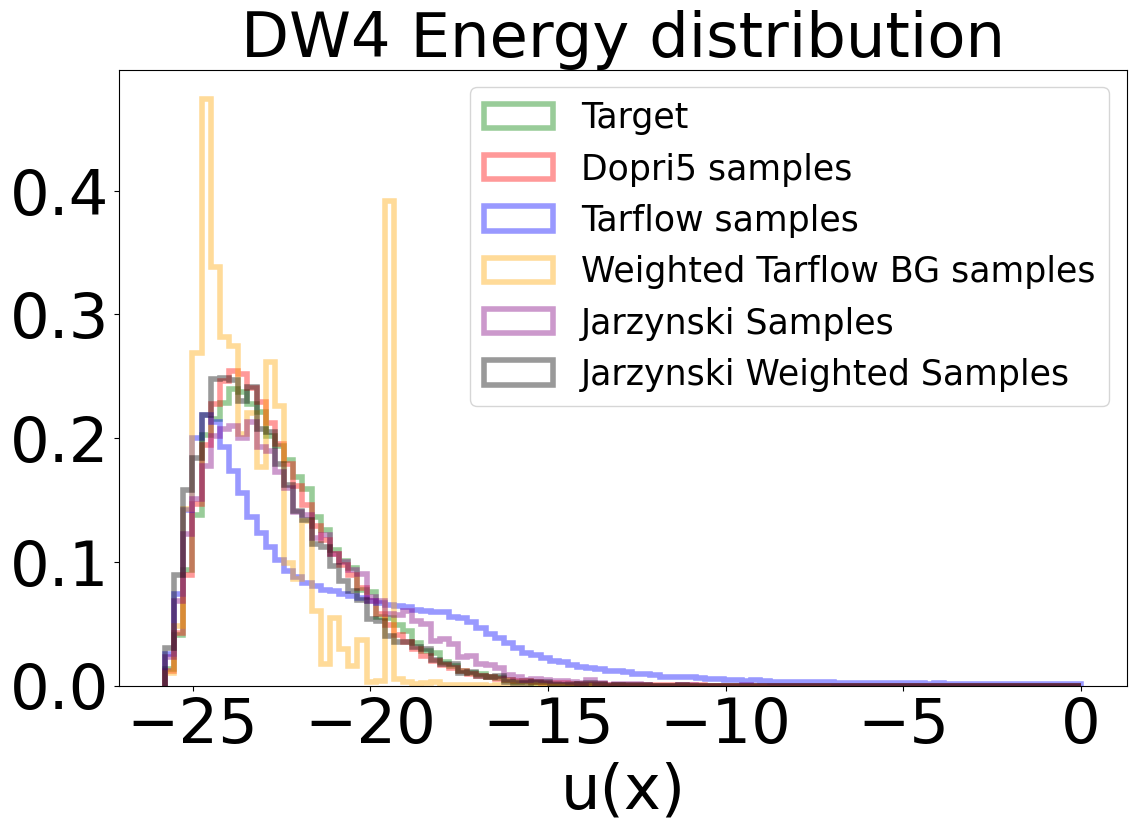

In [56]:

energies_jarzynski = target.energy(jarzynski_samples).detach().cpu().numpy().flatten()
energies_data = target.energy(data).detach().cpu().numpy().flatten()
#energies_bg = target.energy(x1).detach().cpu().numpy().flatten()
energies_bg = target.energy(dopri_samples).detach().cpu().numpy().flatten()
energies_flow = target.energy(x1).detach().cpu().numpy().flatten()
log_weights = - energies_flow - log_probs.detach().cpu().numpy()

log_jarzynski_weights = -(jarzynski_weights).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_bg.min())
max_energy = max(energies_data.max(), energies_bg.max())

plt.figure(figsize=(13,8))
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label=f"Dopri5 samples");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Tarflow samples");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="orange", label=f"Weighted Tarflow BG samples", weights=torch.softmax(torch.from_numpy(log_weights), dim=0))
plt.hist(energies_jarzynski, bins=100, density=True,  
         range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="purple", label=f"Jarzynski Samples")
plt.hist(energies_jarzynski, bins=100, density=True,  
         range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="black", label=f"Jarzynski Weighted Samples", weights=jarzynski_weights.detach().cpu().numpy())

#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [ ]:
energies_data = target.energy(data).detach().cpu().numpy().flatten()
#energies_bg = target.energy(x1).detach().cpu().numpy().flatten()
energies_bg = target.energy(dopri_samples).detach().cpu().numpy().flatten()
energies_flow = target.energy(x1).detach().cpu().numpy().flatten()
log_weights = - energies_flow - log_probs.detach().cpu().numpy()
min_energy = min(energies_data.min(), energies_bg.min())
max_energy = max(energies_data.max(), energies_bg.max())

plt.figure(figsize=(13,8))
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label=f"Dopri5 samples");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Tarflow samples");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="orange", label=f"Weighted Tarflow BG samples", weights=torch.softmax(torch.from_numpy(log_weights), dim=0))

#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [ ]:


energies_data = target.energy(data).detach().cpu().numpy().flatten()
#energies_bg = target.energy(x1).detach().cpu().numpy().flatten()
energies_bg = target.energy(dopri_samples).detach().cpu().numpy().flatten()
energies_flow = target.energy(x1).detach().cpu().numpy().flatten()
log_weights = - energies_flow - log_probs.detach().cpu().numpy()
min_energy = min(energies_data.min(), energies_bg.min())
max_energy = max(energies_data.max(), energies_bg.max())

plt.figure(figsize=(13,8))
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label=f"BG samples");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Tarflow samples");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="orange", label=f"Weighted Tarflow BG samples", weights=torch.softmax(torch.from_numpy(log_weights), dim=0))

#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [ ]:
from bgflow.bg import sampling_efficiency
sampling_efficiency(torch.from_numpy(log_weights)).item()

In [ ]:
torch.from_numpy(log_weights).shape

In [ ]:
log_weights

In [ ]:
np.isnan(log_weights).mean()

In [ ]:
weights.mean()

In [ ]:
torch.softmax(torch.from_numpy(log_weights), dim=0)

In [ ]:
torch.isnan(log_probs).sum()

In [38]:
prior_energy(X_0)

tensor([12.6125, 12.3889, 18.1623, 17.9526, 11.9638, 18.6052, 13.4882, 12.6281,
        14.1275, 13.5225, 18.5277, 12.4605, 18.6514, 18.9633, 15.9402, 12.5917,
        10.5231, 11.7802, 11.8163, 18.6624, 14.3413, 11.4186, 17.2631, 10.4777,
        18.8305, 11.5910, 17.6230, 12.1628, 12.6941, 15.1322, 12.5501, 19.1830,
        18.6015, 17.0522, 18.4987, 18.4091, 12.3780, 18.5592, 18.5322, 12.4349,
        13.4972, 14.6629, 18.1609, 17.4239, 11.3660, 17.1567, 13.1184, 17.3933,
        17.2811, 18.4172,  9.6101, 18.4248, 12.8600, 11.8847, 15.2134, 19.7596,
        19.7240, 12.6930, 18.4102, 10.5831, 17.6057, 19.7435, 19.3852, 19.3695,
        18.7942,  9.3191, 16.2716, 20.1161, 13.0748, 13.7305, 12.4790, 12.4350,
        19.0429, 12.5245, 13.1735, 13.7765, 19.3414,  9.7897, 18.5424, 12.7610,
        19.1116, 17.4791, 19.3313, 13.3328, 19.1706, 13.8895, 19.0277, 11.9767,
        13.6698, 18.3822, 12.7401,  9.5750,  9.7234, 12.0021, 12.7993, 19.9724,
        18.2088, 12.9429, 12.1212, 17.00